Hypothesis Testing on Advertisement Conversion Rates

Conducted statistical hypothesis testing on advertising campaign data to analyze whether users exposed to advertisements had higher conversion rates compared to users shown public service announcements (PSA).
Performed data cleaning, exploratory data analysis (EDA), and conversion rate comparison using Python libraries such as Pandas, NumPy, SciPy, and Matplotlib.

In [1]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv('/kaggle/input/datasets/faviovaz/marketing-ab-testing/marketing_AB.csv')

# Display first rows
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# Remove unused columns
df.drop(columns=['Unnamed: 0', 'user id'], inplace=True)

# Display first rows
df.head()

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14


In [4]:
# Basic shape and info
print("Shape:", df.shape)
print(df.info())

# Summary stats for numeric columns
df.describe().T

Shape: (588101, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   test group     588101 non-null  object
 1   converted      588101 non-null  bool  
 2   total ads      588101 non-null  int64 
 3   most ads day   588101 non-null  object
 4   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(2), object(2)
memory usage: 18.5+ MB
None


,count,mean,std,min,25%,50%,75%,max
total ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,14.469061,4.834634,0.0,11.0,14.0,18.0,23.0


In [5]:
# Unique values
print("Test group:", df['test group'].unique())
print("Converted:", df['converted'].unique())
print("Most ads day:", df['most ads day'].unique())

Test group: ['ad' 'psa']
Converted: [False  True]
Most ads day: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']


In [6]:
df['converted']

0         False
1         False
2         False
3         False
4         False
          ...  
588096    False
588097    False
588098    False
588099    False
588100    False
Name: converted, Length: 588101, dtype: bool

In [7]:
# Convert boolean to integer for numerical tests
df['converted'] = df['converted'].astype(int)

df.dtypes

test group       object
converted         int64
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [8]:
df['converted']

0         0
1         0
2         0
3         0
4         0
         ..
588096    0
588097    0
588098    0
588099    0
588100    0
Name: converted, Length: 588101, dtype: int64

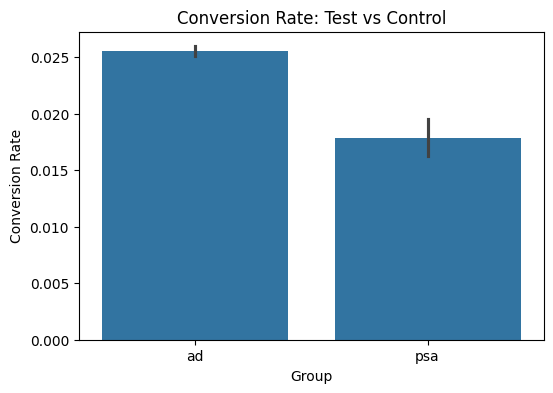

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='test group', y='converted')
plt.title("Conversion Rate: Test vs Control")
plt.xlabel("Group")
plt.ylabel("Conversion Rate")
plt.show()

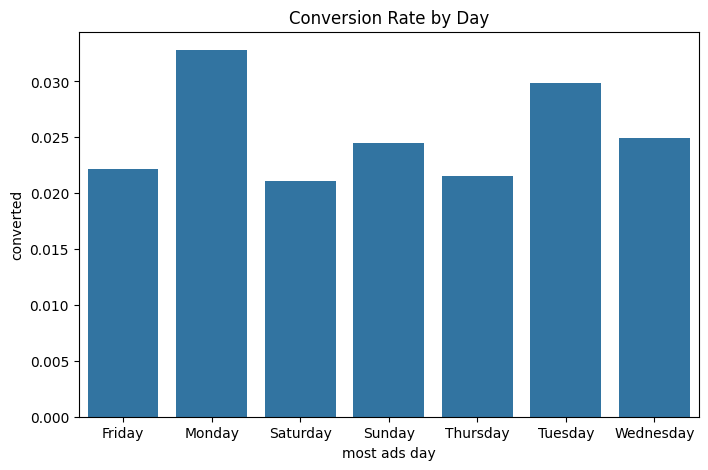

In [10]:
day_rate = df.groupby('most ads day')['converted'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=day_rate, x='most ads day', y='converted')
plt.title("Conversion Rate by Day")
plt.show()

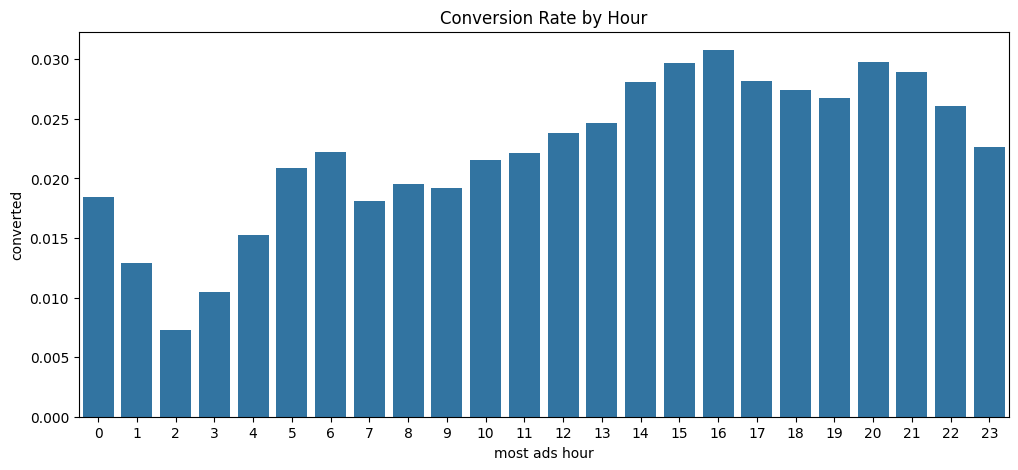

In [11]:
hour_rate = df.groupby('most ads hour')['converted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=hour_rate, x='most ads hour', y='converted')
plt.title("Conversion Rate by Hour")
plt.show()

In [12]:
control_group = df[df['test group'] == 'psa']
test_group = df[df['test group'] == 'ad']

control_conv = control_group['converted']
test_conv = test_group['converted']

t_stat , p_val = stats.ttest_ind(test_conv , control_conv)

print("t-statistic:", t_stat)
print("P-value:", p_val)

if p_val < 0.05:
    print("Result: Reject H0 -> Significant difference in conversion rates")
else:
    print("Result: Fail to reject h0 -> No significant difference")

t-statistic: 7.37040597428566
P-value: 1.7033052627831264e-13
Result: Reject H0 -> Significant difference in conversion rates
